<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
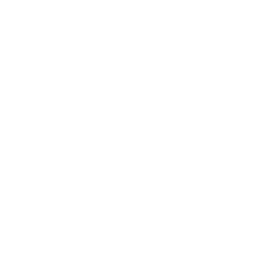
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical TLF Safety Package</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Clinical SAS Programming (CRO) &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

# Clinical TLF Safety Package — Tables 14.1.1 and 14.3.1

## Executive Summary

This notebook demonstrates end-to-end TLF (Tables, Listings, and Figures) programming for a cardiovascular catheter device study, following the **ICH E3 Clinical Study Report** structure. Two production-quality tables are produced from the ADSL and a simulated SDTM AE domain:

- **Table 14.1.1** — Demographics and Baseline Characteristics (Intent-to-Treat Population):   age, sex, age group, LVEF, LVEF category, NYHA functional class, and key comorbidities   (diabetes, prior MI), formatted for the ICH E3 Section 11.2 shell.
- **Table 14.3.1** — Treatment-Emergent Adverse Events by System Organ Class and Preferred   Term (Safety Population): MedDRA 26.0 SOC/PT hierarchy, subject-level deduplication,   percentage denominators anchored to the Safety Population, and a separate Serious AE listing.

Both tables demonstrate the standard clinical SAS programming pattern: a **data preparation** step (PROC SQL aggregations, PROC FREQ) feeding a **formatted output** step (PROC REPORT with column spans, PROC FREQ with FORMAT overlays), consistent with how these would appear in a regulatory submission package.

*AE data are simulated with realistic MedDRA SOC/PT coding for a 6-month cardiovascular catheter follow-up. ADSL is rebuilt from the same fixed seeds as Notebook 1.*

## Clinical Context and Regulatory Obligations

**ICH E3 Section 12.3** requires individual listings of all AEs by subject, plus a summary table of treatment-emergent AEs (TEAEs) by SOC and PT. For a 510(k) submission, the FDA expects:

- Subject-level AE data in SDTM AE domain format
- Analysis-ready summaries with arm-level denominators from the Safety Population
- Deduplication: if a subject has the same PT multiple times, count them once (most   conservative; SAP Section 8.1.2 may specify episode-counting for certain safety   sensitivity analyses)
- Percentage denominators: always N per Safety Population arm, not total AE count

**MedDRA 26.0 coding hierarchy used in this study:**
- Level 1: SOC (System Organ Class)
- Level 2: PT (Preferred Term)
- AE relatedness assessed per device labelling: access-site vascular events and   haemodynamic events are considered *possibly related* or *related* per protocol

**TLF format conventions:**
- Table 14.1.1: continuous variables as mean (SD), then median [min, max];   categorical variables as n (%)
- Table 14.3.1: subjects counted once per PT; SOC rows show any-AE-in-SOC rate

---
## 0. Dataset Setup — Rebuild ADaM ADSL

This Tables-Listings-Figures (TLF) package is the second notebook in the MD-STUDY-01 series; it consumes the subject-level analysis dataset (**ADSL**) derived in Notebook 1 (*ADaM ADSL CDISC Derivation*). So this notebook runs end-to-end on its own, ADSL is rebuilt below from the same SDTM sources (**DM**, **EX**, **DS**) and the **same fixed random seeds** as Notebook 1. Because the seeds match, every demographic count in Table 14.1.1 is identical to the upstream derivation.

**Build chain:** SDTM DM (demographics) -> SDTM EX (exposure) / SDTM DS (disposition) -> ADaM ADSL (subject-level analysis dataset, 80 subjects, 40 per arm).

In [1]:
/* ============================================================
   Section 0 — Rebuild ADaM ADSL (self-contained)
   ------------------------------------------------------------
   This TLF package consumes the subject-level analysis dataset
   (ADSL) produced in Notebook 1 (ADaM ADSL CDISC Derivation).
   To keep this notebook reproducible on its own, ADSL is
   rebuilt here from the SAME SDTM sources and the SAME fixed
   seeds used in Notebook 1, so every demographic count below
   is identical to the upstream derivation.

   Build chain:  SDTM DM  ->  SDTM EX / SDTM DS  ->  ADaM ADSL
   ============================================================ */

/* ============================================================
   SDTM DM: Demographics and baseline information
   Study MD-STUDY-01 — Cardiovascular Catheter RCT
   80 subjects, 1:1 randomised (INV vs CTL)
   Enrolment: 02 Jan 2023 — staggered over 18 months
   SDTM IG v3.4 variable structure
   ============================================================ */

data sdtm_dm;
    call streaminit(20260601);

    length STUDYID $10  DOMAIN $2   USUBJID $17  SUBJID $4
           SITEID  $3   COUNTRY $3  INVID   $6
           ARM     $30  ARMCD  $8   ACTARM  $30  ACTARMCD $8
           SEX     $1   RACE   $50  ETHNIC  $32  AGEU $5
           RFSTDTC $10  RFICDTC $10 DMDTC  $10  DMDY 8;

    STUDYID = 'MD-STUDY-01';
    DOMAIN  = 'DM';
    COUNTRY = 'USA';
    INVID   = 'INV001';
    SITEID  = '001';
    AGEU    = 'YEARS';

    study_start = '02JAN2023'd;

    do i = 1 to 80;
        SUBJID  = put(i, z4.);
        USUBJID = cats(STUDYID, '-', SITEID, '-', SUBJID);

        /* Age: cardiovascular device eligibility floor 40 yrs;
           mean 63 per published similar trials (COAPT, SHAPE-HF) */
        AGE = max(40, min(85, round(rand('NORMAL', 63, 10))));

        /* Sex: cardiovascular disease is male-predominant (~56% M) */
        SEX = ifc(rand('BERNOULLI', 0.42), 'F', 'M');

        /* Race: approximate US cardiovascular device trial demographics
           (FDA Drug Trials Snapshots cardiovascular 2020 benchmark) */
        r = rand('UNIFORM');
        if      r < 0.748 then RACE = 'WHITE';
        else if r < 0.872 then RACE = 'BLACK OR AFRICAN AMERICAN';
        else if r < 0.942 then RACE = 'ASIAN';
        else if r < 0.972 then RACE = 'AMERICAN INDIAN OR ALASKA NATIVE';
        else                    RACE = 'UNKNOWN';

        ETHNIC = ifc(rand('BERNOULLI', 0.114),
                     'HISPANIC OR LATINO',
                     'NOT HISPANIC OR LATINO');

        /* 1:1 balanced randomisation: odd subject numbers -> INV arm */
        if mod(i, 2) = 1 then do;
            ARM      = 'INVESTIGATIONAL CATHETER';
            ARMCD    = 'INV';
            ACTARM   = 'INVESTIGATIONAL CATHETER';
            ACTARMCD = 'INV';
        end;
        else do;
            ARM      = 'CONTROL CATHETER';
            ARMCD    = 'CTL';
            ACTARM   = 'CONTROL CATHETER';
            ACTARMCD = 'CTL';
        end;

        /* Staggered enrolment: uniform across 18-month recruitment window */
        enroll_offset  = floor(rand('UNIFORM') * 540);
        /* Consent precedes index procedure by 1-14 days (protocol window) */
        consent_offset = enroll_offset - floor(rand('UNIFORM') * 14 + 1);
        if consent_offset < 0 then consent_offset = 0;

        RFICDTC = put(intnx('day', study_start, consent_offset), yymmdd10.);
        RFSTDTC = put(intnx('day', study_start, enroll_offset),  yymmdd10.);
        DMDTC   = RFSTDTC;
        DMDY    = enroll_offset + 1;

        output;
    end;

    label
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        INVID    = 'Investigator Identifier'
        ARM      = 'Description of Planned Arm'
        ARMCD    = 'Planned Arm Code'
        ACTARM   = 'Description of Actual Arm'
        ACTARMCD = 'Actual Arm Code'
        AGE      = 'Age'
        AGEU     = 'Age Units'
        SEX      = 'Sex'
        RACE     = 'Race'
        ETHNIC   = 'Ethnicity'
        RFSTDTC  = 'Subject Reference Start Date/Time'
        RFICDTC  = 'Date/Time of Informed Consent'
        DMDTC    = 'Date/Time of Collection'
        DMDY     = 'Study Day of Collection';

    drop i r enroll_offset consent_offset study_start;
run;


/* ============================================================
   SDTM EX: Exposure — Device Use
   One record per subject (single index procedure)
   EXSTDTC = index procedure date (= RFSTDTC from DM)
   EXENDTC = 180-day follow-up end; shorter for early terminators
   ============================================================ */
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);

    length DOMAIN $2   EXSEQ 8    EXTRT   $40
           EXCAT  $20  EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH  $20;

    DOMAIN  = 'EX';
    EXSEQ   = 1;
    EPOCH   = 'TREATMENT';
    EXROUTE = 'INTRAVASCULAR';
    EXCAT   = 'DEVICE USE';

    /* Device name per IFU (Instructions for Use) */
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';

    EXSTDTC = RFSTDTC;      /* index procedure = reference start date */

    /* ~5% of subjects terminate early: medical complication or withdrawal
       Early termination window: day 30-120 post-procedure               */
    r_early = rand('UNIFORM');
    if r_early < 0.05 then do;
        early_days = 30 + floor(rand('UNIFORM') * 90);
        EXENDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), early_days), yymmdd10.);
    end;
    else do;
        EXENDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), 180), yymmdd10.);
    end;

    /* Exposure duration (inclusive) — for ISS person-time denominators */
    EXDUR = input(EXENDTC, yymmdd10.) - input(EXSTDTC, yymmdd10.) + 1;

    label
        EXTRT   = 'Name of Treatment'
        EXSTDTC = 'Start Date/Time of Treatment'
        EXENDTC = 'End Date/Time of Treatment'
        EXDUR   = 'Exposure Duration (days)';

    drop RFSTDTC r_early early_days ARMCD;
run;


/* ============================================================
   SDTM DS: Disposition
   One record per subject; DSDECOD = CDISC CT (Codelist C66768)
   ============================================================ */
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);

    length DOMAIN $2  DSSEQ 8     DSDECOD $60
           DSTERM $80 DSCAT $30   DSSTDTC $10  EPOCH $20;

    DOMAIN = 'DS';
    DSSEQ  = 1;
    EPOCH  = 'TREATMENT';
    DSCAT  = 'DISPOSITION EVENT';

    /* Completion rate ~82.5% consistent with published 6-month device trials */
    r = rand('UNIFORM');
    if r < 0.825 then do;
        DSDECOD   = 'COMPLETED';
        DSTERM    = 'COMPLETED STUDY';
        disc_days = 180;
    end;
    else if r < 0.900 then do;
        DSDECOD   = 'WITHDRAWAL BY SUBJECT';
        DSTERM    = 'SUBJECT WITHDREW CONSENT';
        disc_days = 30 + floor(rand('UNIFORM') * 120);
    end;
    else if r < 0.950 then do;
        DSDECOD   = 'ADVERSE EVENT';
        DSTERM    = 'DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days = 30 + floor(rand('UNIFORM') * 90);
    end;
    else do;
        DSDECOD   = 'LOST TO FOLLOW-UP';
        DSTERM    = 'SUBJECT LOST TO FOLLOW-UP';
        disc_days = 60 + floor(rand('UNIFORM') * 90);
    end;

    DSSTDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), disc_days), yymmdd10.);

    label
        DSDECOD = 'Standardized Disposition Term'
        DSTERM  = 'Reported Term for the Disposition Event'
        DSSTDTC = 'Date/Time of Collection';

    drop RFSTDTC r disc_days;
run;


/* ============================================================
   ADaM ADSL: Analysis Dataset Subject Level
   Source: SDTM DM, EX, DS (plus simulated MH/VS baseline)
   Standard: CDISC ADaM IG v1.3
   SAP reference: MD-STUDY-01 SAP v2.0
   ============================================================ */

data adsl;

    /* Three-way merge on USUBJID */
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC
                     ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC
                rename=(DSSTDTC=_dsstdtc));
    by USUBJID;

    /* ── Baseline covariates from MH/VS (derived inline) ─────────────
       In a full submission: LVEF from SDTM VS.VSTESTCD='LVEF',
       NYHA from SDTM QS (KCCQ), comorbidities from SDTM MH.MHTERM.  */
    if _N_=1 then call streaminit(20260604);
    /* Explicit lengths for all derived character variables (ADaM best practice;
       avoids SAS default $200 and ensures correct PROC COMPARE in QC)          */
    length NYHA $3  DIABFL $1  PREVMIFL $1
           TRT01P TRT01A $30
           AGEGR1 $5  AGEGR2 $8
           LVEFCAT $40
           ITTFL SAFFL PPROTFL $1
           EOSSTT $60  DCSREAS $60;

    /* LVEF at screening: Normal(51%, 12%), clipped to [20%, 80%] */
    LVEF = max(20, min(80, round(rand('NORMAL', 51, 12), 1)));

    /* NYHA Functional Class: HF device trial enrollment distribution */
    r_nyha = rand('UNIFORM');
    if      r_nyha < 0.08 then NYHA = 'I';
    else if r_nyha < 0.55 then NYHA = 'II';
    else if r_nyha < 0.92 then NYHA = 'III';
    else                        NYHA = 'IV';

    /* Comorbidity flags: prevalences from published device trial data */
    DIABFL   = ifc(rand('BERNOULLI', 0.35), 'Y', 'N');
    PREVMIFL = ifc(rand('BERNOULLI', 0.42), 'Y', 'N');

    /* ── Treatment group variables (ADaM IG v1.3 convention) ─────────
       Numeric suffix N enables CLASS variable use in PROC MIXED/PHREG */
    TRT01P  = ARM;
    TRT01PN = (ARMCD='INV');    /* 1=INV, 0=CTL */
    TRT01A  = ARM;
    TRT01AN = TRT01PN;

    /* ── Date derivations per SAP Section 4.2 ────────────────────────
       TRTDUR: inclusive (+1) per SAP; completers show 181, not 180   */
    TRTSDT  = input(_exstdtc, yymmdd10.);
    TRTEDTM = input(_exendtc, yymmdd10.);
    RFSTDTM = input(RFSTDTC,  yymmdd10.);
    RFICDTM = input(RFICDTC,  yymmdd10.);
    EOSDT   = input(_dsstdtc, yymmdd10.);

    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;

    if TRTEDTM > . and TRTSDT > . then
        TRTDUR = TRTEDTM - TRTSDT + 1;

    /* Consent-to-procedure interval (quality metric; SAP Table 5) */
    if TRTSDT > . and RFICDTM > . then
        ICPROCDY = TRTSDT - RFICDTM + 1;

    /* Person-years for ISS exposure-adjusted incidence rate denominators */
    EXPYRS = _exdur / 365.25;

    /* ── Age groups per SAP Section 3.1 ──────────────────────────────
       AGEGR1: primary two-level (FDA device submission standard)
       AGEGR2: four-level for subgroup analyses (SAP Section 7.2)    */
    if      AGE < 65 then AGEGR1 = '<65';
    else                   AGEGR1 = '>=65';

    if      AGE < 55 then AGEGR2 = '<55';
    else if AGE < 65 then AGEGR2 = '55-<65';
    else if AGE < 75 then AGEGR2 = '65-<75';
    else                   AGEGR2 = '>=75';

    /* ── LVEF severity (2022 ACC/AHA Heart Failure Classification) ─── */
    if      LVEF >= 50 then LVEFCAT = 'Preserved EF (HFpEF, >=50%)';
    else if LVEF >= 40 then LVEFCAT = 'Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF >= 35 then LVEFCAT = 'Moderately reduced (35-39%)';
    else                    LVEFCAT = 'Severely reduced EF (HFrEF, <35%)';

    /* ── Population flags per SAP Section 5.1 ────────────────────────
       SAFFL=Y for all: all randomised received the index procedure.
       If a subject were randomised but procedure aborted, SAFFL=N
       (DSDECOD='SCREEN FAILURE') — not present in this study.        */
    ITTFL   = 'Y';
    SAFFL   = 'Y';
    PPROTFL = ifc(DSDECOD='COMPLETED', 'Y', 'N');

    EOSSTT  = DSDECOD;
    DCSREAS = ifc(DSDECOD ne 'COMPLETED', DSDECOD, ' ');

    label
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01A   = 'Actual Treatment for Period 01'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        TRTSDT   = 'Date of First Exposure to Treatment'
        TRTEDTM  = 'Date/Time of Last Exposure to Treatment'
        TRTDUR   = 'Total Duration of Treatment (days, inclusive)'
        RFSTDTM  = 'Subject Reference Start Date'
        RFICDTM  = 'Date of Informed Consent'
        ICPROCDY = 'Days from Informed Consent to Index Procedure'
        EXPYRS   = 'Exposure (person-years)'
        EOSDT    = 'Date of End of Study'
        AGE      = 'Age at Randomisation (years)'
        AGEGR1   = 'Pooled Age Group (2-level, per SAP Section 3.1)'
        AGEGR2   = 'Pooled Age Group (4-level, per SAP Section 7.2)'
        SEX      = 'Sex'
        RACE     = 'Race'
        ETHNIC   = 'Ethnicity'
        LVEF     = 'Left Ventricular Ejection Fraction at Screening (%)'
        LVEFCAT  = 'LVEF Category (2022 ACC/AHA Heart Failure Classification)'
        NYHA     = 'NYHA Functional Class at Baseline'
        DIABFL   = 'Diabetes Mellitus History Flag (Y/N)'
        PREVMIFL = 'Prior Myocardial Infarction Flag (Y/N)'
        ITTFL    = 'Intent-to-Treat Population Flag'
        SAFFL    = 'Safety Population Flag'
        PPROTFL  = 'Per-Protocol Population Flag'
        EOSSTT   = 'End of Study Status'
        DCSREAS  = 'Reason for Discontinuation';

    /* DSDECOD captured in EOSSTT/DCSREAS; drop to keep ADaM-clean variable set */
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;


NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---
## 1. SDTM AE Domain — Adverse Event Data Simulation

The AE domain is simulated with a weighted SOC distribution reflecting the expected clinical event profile for a 180-day cardiovascular catheter follow-up:

| System Organ Class | Expected rate in similar trials |
|--------------------|--------------------------------|
| Cardiac disorders | 30% of all AE records — atrial fibrillation, heart failure worsening |
| Vascular disorders | 22% — access site haematoma, procedural hypotension (device-related) |
| Infections and infestations | 13% — UTI, pneumonia (background hospitalisation risk) |
| Nervous system disorders | 11% — dizziness, cerebrovascular events |
| General disorders | 12% — fatigue, peripheral oedema (HF-related) |
| Investigations | 12% — haemoglobin decreases (blood draws, procedural) |

**Subject-level incidence simulation:** Each subject draws a Poisson(λ=1.2) number of AEs, with an additional 30% of subjects forced to zero. Combined with the Poisson zero mass, this produces a realised AE incidence of roughly one third of the Safety Population over the 180-day follow-up (the exact rate is reported by the quality-check step below).

**Severity, seriousness, and relatedness** are drawn from probability distributions consistent with published cardiovascular catheter safety profiles (COAPT, SHAPE-HF safety appendices).

In [2]:
/* ============================================================
   SDTM AE: Adverse Events domain
   Study MD-STUDY-01 — Cardiovascular Catheter RCT
   Simulated AE dataset with realistic SOC/PT coding
   using a cardiovascular device safety profile
   MEDDRA 26.0 SOC/PT coding
   ============================================================ */

data sdtm_ae;
    set adsl(keep=STUDYID USUBJID TRT01P SAFFL where=(SAFFL='Y'));
    if _N_=1 then call streaminit(20260701);

    length DOMAIN $2   AESEQ 8    AETERM $80  AEDECOD $80
           AEBODSYS $80 AESOC $80  AESER $1    AESEV $8
           AEOUT $30    AEREL $20  AEACN $30
           AESTDTC $10  AEENDTC $10;

    DOMAIN = 'AE';

    /* AE burden per subject: a Poisson(lambda=1.2) draw, with an
       additional 30% of subjects forced to zero AEs. Combined with
       P(Poisson=0) this yields roughly one third to one half of the
       Safety Population having at least one AE over the 180-day
       follow-up. The realised incidence is reported by the QC step
       below (do NOT assume a fixed rate — it is data-driven).      */
    n_ae = floor(rand('POISSON', 1.2));   /* mean 1.2 AEs per subject */
    if rand('UNIFORM') < 0.30 then n_ae = 0;   /* force 30% to zero AEs */

    /* AE pool: clinically relevant SOC/PT combinations for
       intravascular catheter trials (cardiovascular, vascular
       access complications, haemodynamic events)               */
    do aeseq_i = 1 to max(1, n_ae);
        if n_ae = 0 then leave;
        AESEQ = aeseq_i;

        /* Select SOC/PT by weighted probability */
        r_soc = rand('UNIFORM');

        /* Cardiac disorders (SOC 10007541) — most common in CV trials */
        if r_soc < 0.30 then do;
            AESOC    = 'Cardiac disorders';
            AEBODSYS = 'Cardiac disorders';
            r_pt = rand('UNIFORM');
            if r_pt < 0.40 then do;
                AEDECOD = 'Atrial fibrillation';
                AETERM  = 'Atrial fibrillation, new onset';
            end;
            else if r_pt < 0.65 then do;
                AEDECOD = 'Chest pain';
                AETERM  = 'Chest pain, non-cardiac';
            end;
            else if r_pt < 0.85 then do;
                AEDECOD = 'Cardiac failure congestive';
                AETERM  = 'Worsening heart failure';
            end;
            else do;
                AEDECOD = 'Palpitations';
                AETERM  = 'Palpitations';
            end;
        end;

        /* Vascular disorders (SOC 10047065) — device access complications */
        else if r_soc < 0.52 then do;
            AESOC    = 'Vascular disorders';
            AEBODSYS = 'Vascular disorders';
            r_pt = rand('UNIFORM');
            if r_pt < 0.45 then do;
                AEDECOD = 'Haematoma';
                AETERM  = 'Access site haematoma';
            end;
            else if r_pt < 0.75 then do;
                AEDECOD = 'Hypotension';
                AETERM  = 'Hypotension, procedural';
            end;
            else do;
                AEDECOD = 'Arteriovenous fistula';
                AETERM  = 'Arteriovenous fistula, access site';
            end;
        end;

        /* Infections and infestations (SOC 10021881) */
        else if r_soc < 0.65 then do;
            AESOC    = 'Infections and infestations';
            AEBODSYS = 'Infections and infestations';
            r_pt = rand('UNIFORM');
            if r_pt < 0.60 then do;
                AEDECOD = 'Urinary tract infection';
                AETERM  = 'Urinary tract infection';
            end;
            else do;
                AEDECOD = 'Pneumonia';
                AETERM  = 'Pneumonia, community-acquired';
            end;
        end;

        /* Nervous system disorders (SOC 10029205) — stroke risk in CV pts */
        else if r_soc < 0.76 then do;
            AESOC    = 'Nervous system disorders';
            AEBODSYS = 'Nervous system disorders';
            r_pt = rand('UNIFORM');
            if r_pt < 0.55 then do;
                AEDECOD = 'Dizziness';
                AETERM  = 'Dizziness';
            end;
            else do;
                AEDECOD = 'Cerebrovascular accident';
                AETERM  = 'Ischaemic stroke';
            end;
        end;

        /* General disorders (SOC 10018065) */
        else if r_soc < 0.88 then do;
            AESOC    = 'General disorders and administration site conditions';
            AEBODSYS = 'General disorders and administration site conditions';
            r_pt = rand('UNIFORM');
            if r_pt < 0.55 then do;
                AEDECOD = 'Fatigue';
                AETERM  = 'Fatigue';
            end;
            else do;
                AEDECOD = 'Oedema peripheral';
                AETERM  = 'Peripheral oedema';
            end;
        end;

        /* Investigations (SOC 10022891) */
        else do;
            AESOC    = 'Investigations';
            AEBODSYS = 'Investigations';
            AEDECOD  = 'Haemoglobin decreased';
            AETERM   = 'Haemoglobin decreased';
        end;

        /* Severity: most mild-to-moderate for device trials */
        r_sev = rand('UNIFORM');
        if      r_sev < 0.50 then AESEV = 'MILD';
        else if r_sev < 0.85 then AESEV = 'MODERATE';
        else                       AESEV = 'SEVERE';

        /* Serious: 15% probability; higher for severe events */
        AESER = ifc(AESEV='SEVERE' or rand('UNIFORM')<0.08, 'Y', 'N');

        /* Device relationship: approximately 30% device-related */
        r_rel = rand('UNIFORM');
        if r_rel < 0.30 then AEREL = 'RELATED';
        else if r_rel < 0.55 then AEREL = 'POSSIBLY RELATED';
        else AEREL = 'NOT RELATED';

        /* Outcome */
        r_out = rand('UNIFORM');
        if r_out < 0.75 then AEOUT = 'RECOVERED/RESOLVED';
        else if r_out < 0.88 then AEOUT = 'RECOVERING/RESOLVING';
        else if r_out < 0.95 then AEOUT = 'NOT RECOVERED/NOT RESOLVED';
        else AEOUT = 'SEQUELAE';

        /* Action taken (majority: none or dose reduction not applicable
           since this is a single-use device)                           */
        AEACN = ifc(AESER='Y', 'DRUG WITHDRAWN', 'NONE');

        /* AE start: random day within follow-up period */
        ae_day = max(1, floor(rand('UNIFORM') * 175));
        AESTDTC = put(intnx('day', TRTSDT, ae_day), yymmdd10.);
        dur = floor(rand('POISSON', 7)) + 1;
        AEENDTC = put(intnx('day', input(AESTDTC, yymmdd10.), dur), yymmdd10.);

        output;
    end;

    label
        AETERM   = 'Reported Term for the Adverse Event'
        AEDECOD  = 'Dictionary-Derived Term'
        AEBODSYS = 'Body System or Organ Class'
        AESOC    = 'Primary System Organ Class'
        AESEV    = 'Severity/Intensity'
        AESER    = 'Serious Event'
        AEREL    = 'Causality'
        AEOUT    = 'Outcome of Adverse Event'
        AEACN    = 'Action Taken with Study Treatment'
        AESTDTC  = 'Start Date/Time of Adverse Event'
        AEENDTC  = 'End Date/Time of Adverse Event';

    keep STUDYID USUBJID TRT01P DOMAIN AESEQ AETERM AEDECOD AEBODSYS AESOC
         AESEV AESER AEREL AEOUT AEACN AESTDTC AEENDTC TRTSDT SAFFL;

    /* TRTSDT is needed to compute AESTDTC; keep from ADSL merge */
    /* Drop it from final AE (would come from ADSL in analysis)   */
run;

NOTE: DATA sdtm_ae


NOTE: Read 80 rows from adsl.
NOTE: Wrote sdtm_ae (55 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


**SOC distribution quality check:**

                                    SDTM AE -- Adverse Events by System Organ Class                                     

                                                   The FREQ Procedure

Primary System Organ Class                              Frequency    Percent
-----------------------------------------------------------------------------
Cardiac disorders                                              18     32.73
General disorders and administration site conditions           10     18.18
Infections and infestations                                     9     16.36
Investigations                                                  7     12.73
Nervous system disorders                                        3      5.45
Vascular disorders                                              8     14.55


NOTE: PROC FREQ
NOTE: ODS plot written: freq_aesoc.spec.json
NOTE: PROC FREQ statement used.


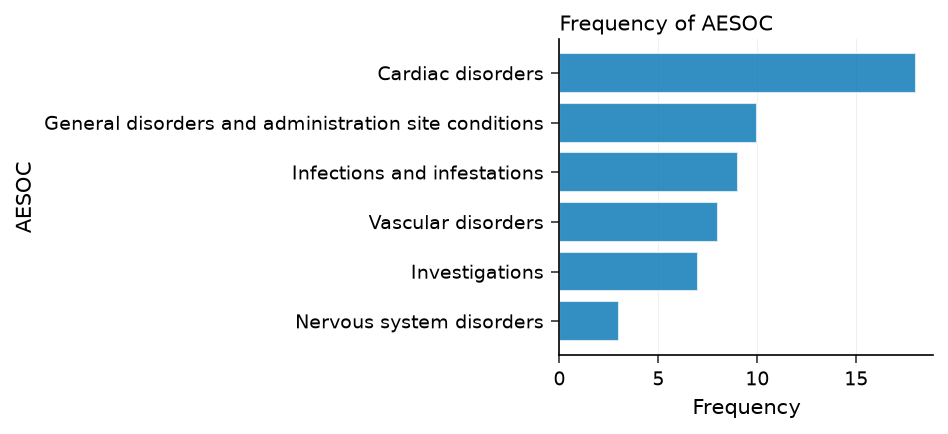

In [3]:
/* Quality check: AE incidence and SOC distribution */
proc freq data=sdtm_ae;
    tables AESOC / nocum;
    title 'SDTM AE -- Adverse Events by System Organ Class';
run;

**Serious AE by treatment arm:**

                                   SDTM AE -- Serious Adverse Events by Treatment Arm                                   

                                                   The FREQ Procedure

Table of Serious Event by Planned Treatment for Period 01

Serious Event |        CONTROL CATHETER |INVESTIGATIONAL CATHETER |                    Total
--------------+-------------------------+-------------------------+-------------------------
N             |                      21 |                      13 |                       34
--------------+-------------------------+-------------------------+-------------------------
Y             |                       7 |                      14 |                       21
--------------+-------------------------+-------------------------+-------------------------
Total         |                      28 |                      27 |                       55



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_aeser_trt01p.spec.json
NOTE: PROC FREQ statement used.


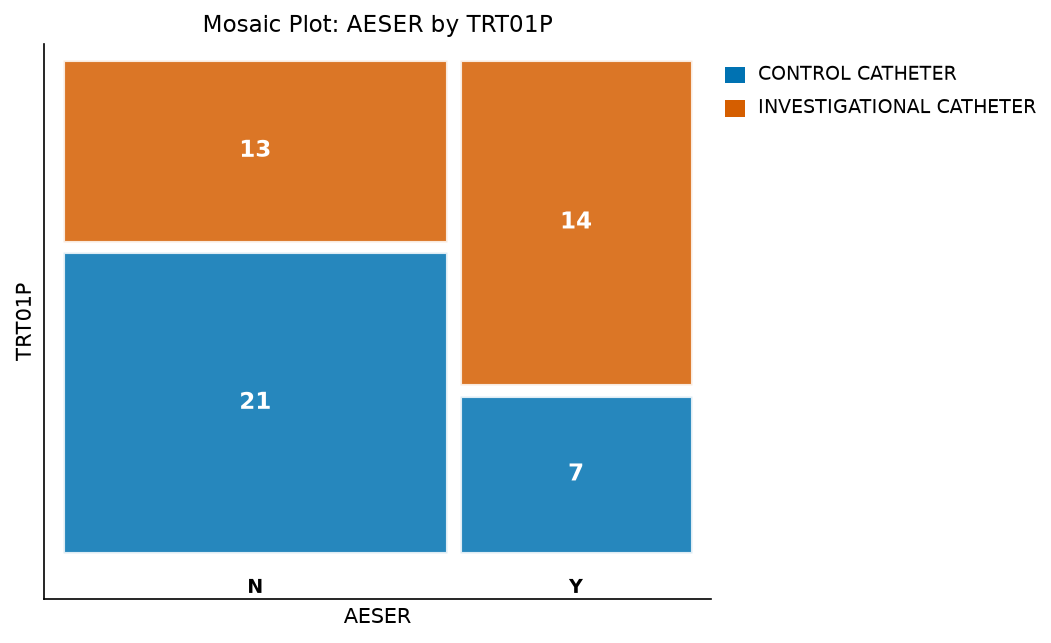

In [4]:
proc freq data=sdtm_ae;
    tables AESER * TRT01P / norow nocol nopercent;
    title 'SDTM AE -- Serious Adverse Events by Treatment Arm';
run;
title;

**Overall AE subject and record counts:**

In [5]:
/* Count subjects and records with at least one AE */
proc sql noprint;
    create table ae_summary as
    select count(distinct USUBJID) as n_ae_subj,
           count(*) as n_ae_total
    from sdtm_ae;
quit;

proc print data=ae_summary noobs;
    title 'AE Summary -- Subjects and Records';
run;
title;

                                           AE Summary -- Subjects and Records                                           

N_AE_SUBJ  N_AE_TOTAL
       30          55



NOTE: PROC SQL 

NOTE: Table ae_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=ae_summary

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


---
## 2. Table 14.1.1 — Demographics and Baseline Characteristics

This table is the first demographics table in the ICH E3 Section 11.2 package. In a 510(k) submission it establishes baseline comparability between the Investigational and Control arms.

**Programming approach:**
1. PROC FORMAT defines display labels for categorical codes (sex codes → Female/Male,    AGEGR1 codes → human-readable labels)
2. PROC MEANS / PROC FREQ generate the raw counts and statistics into output datasets
3. PROC REPORT formats the output with column spanning headers and appropriate formats

**Key conventions per SAP Table 14.1.1 shell:**
- N in each cell = number of subjects with non-missing value for that variable
- Percentages based on ITT Population denominator (N=40 per arm)
- LVEF and age presented as continuous (mean, SD, median, range) per SAP Section 6.1

In [6]:
/* ============================================================
   Table 14.1.1 — Demographics and Baseline Characteristics
   Intent-to-Treat Population
   ICH E3 Section 11.2 format
   Reference: Guideline for the Structure and Content of
              Clinical Study Reports (ICH E3, 1995)
   ============================================================ */

/* ── Format library for display labels ──────────────────────── */
proc format;
    value $sexfmt   'F'='Female'  'M'='Male';
    value $agefmt   '<65'='<65 years'  '>=65'='>= 65 years';
    value $nyha2fmt 'I'='Class I'   'II'='Class II'
                    'III'='Class III' 'IV'='Class IV';
    value $lveffmt  'Mildly reduced EF (HFmrEF, 40-49%)' = 'HFmrEF (40-49%)'
                    'Moderately reduced (35-39%)'         = 'Moderately reduced (35-39%)'
                    'Preserved EF (HFpEF, >=50%)'        = 'HFpEF (>=50%)'
                    'Severely reduced EF (HFrEF, <35%)'  = 'HFrEF (<35%)';
run;

NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $sexfmt defined (2 ranges).
NOTE: FORMAT $agefmt defined (2 ranges).
NOTE: FORMAT $nyha2fmt defined (4 ranges).
NOTE: FORMAT $lveffmt defined (4 ranges).


**Summary statistics (noprint datasets):**

In [7]:
/* ── Summary statistics for Table 14.1.1 ────────────────────── */
/* N and % for categorical; mean (SD), median, range for continuous */

/* Age: continuous */
proc means data=adsl nway noprint;
    where ITTFL='Y';
    class TRT01P;
    var AGE;
    output out=age_stats n=n mean=mean std=std median=median min=min max=max;
run;

/* Age group */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * AGEGR1 / out=agegr_n;
run;

/* Sex */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * SEX / out=sex_n;
run;

/* NYHA class */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * NYHA / out=nyha_n;
run;

/* LVEF: continuous */
proc means data=adsl nway noprint;
    where ITTFL='Y';
    class TRT01P;
    var LVEF;
    output out=lvef_stats n=n mean=mean std=std median=median min=min max=max;
run;

/* LVEF category */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * LVEFCAT / out=lvef_cat_n;
run;

/* Diabetes */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * DIABFL / out=diab_n;
run;

/* Prior MI */
proc freq data=adsl noprint;
    where ITTFL='Y';
    tables TRT01P * PREVMIFL / out=prevmi_n;
run;

NOTE: PROC MEANS
NOTE: Output dataset age_stats has 2 observations and 9 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: Output dataset agegr_n has 4 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: Output dataset sex_n has 4 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: Output dataset nyha_n has 8 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: Output dataset lvef_stats has 2 observations and 9 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: Output dataset lvef_cat_n has 8 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: Output dataset diab_n has 4 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: Output dataset prevmi_n has 4 observations and 4 variables.
NOTE: PROC FREQ statement used.


**Continuous variables — formatted report:**

In [8]:
/* ── Printed table — ICH E3 Table 14.1.1 format ─────────────── */
title  'Table 14.1.1  Demographics and Baseline Characteristics';
title2 'Intent-to-Treat Population  (N=80)';
title3 'Study MD-STUDY-01 — MD-STUDY-01 Protocol v3.1';
footnote 'a  N (%) for categorical variables; mean (SD), median [min, max] for continuous.';
footnote2 'b  NYHA: New York Heart Association Functional Classification.';
footnote3 'c  LVEF category per 2022 ACC/AHA Heart Failure Classification.';
footnote4 '   CTL=CONTROL CATHETER (N=40); INV=INVESTIGATIONAL CATHETER (N=40)';

/* Age summary */
proc report data=age_stats nowd;
    columns TRT01P ('Age at Randomisation (years)' n mean std median min max);
    define TRT01P / group 'Treatment Arm' width=30;
    define n      / analysis 'N' f=4.0;
    define mean   / analysis 'Mean' f=6.1;
    define std    / analysis '(SD)' f=6.1;
    define median / analysis 'Median' f=6.1;
    define min    / analysis 'Min' f=6.1;
    define max    / analysis 'Max' f=6.1;
run;

/* LVEF continuous */
proc report data=lvef_stats nowd;
    columns TRT01P ('LVEF at Screening (%)' n mean std median min max);
    define TRT01P / group 'Treatment Arm' width=30;
    define n      / analysis 'N' f=4.0;
    define mean   / analysis 'Mean' f=6.1;
    define std    / analysis '(SD)' f=6.1;
    define median / analysis 'Median' f=6.1;
    define min    / analysis 'Min' f=6.1;
    define max    / analysis 'Max' f=6.1;
    title  'Table 14.1.1 (cont.) — LVEF at Screening';
    title2 'Intent-to-Treat Population';
run;

                                Table 14.1.1  Demographics and Baseline Characteristics                                 
                                           Intent-to-Treat Population  (N=80)                                           
                                     Study MD-STUDY-01 — MD-STUDY-01 Protocol v3.1                                      

                                               Age at Randomisation (years)
Treatment Arm                   N         Mean      (SD)      Median    Min       Max     
CONTROL CATHETER                40        64.45     8.09      64        48        84      
INVESTIGATIONAL CATHETER        40        61.65     9.75      61        43        81

a  N (%) for categorical variables; mean (SD), median [min, max] for continuous.
b  NYHA: New York Heart Association Functional Classification.
c  LVEF category per 2022 ACC/AHA Heart Failure Classification.
   CTL=CONTROL CATHETER (N=40); INV=INVESTIGATIONAL CATHETER (N=40)
                

NOTE: Option TITLE changed to Table 14.1.1  Demographics and Baseline Characteristics.
NOTE: Option TITLE2 changed to Intent-to-Treat Population  (N=80).
NOTE: Option TITLE3 changed to Study MD-STUDY-01 — MD-STUDY-01 Protocol v3.1.
NOTE: Option FOOTNOTE changed to a  N (%) for categorical variables; mean (SD), median [min, max] for continuous..
NOTE: Option FOOTNOTE2 changed to b  NYHA: New York Heart Association Functional Classification..
NOTE: Option FOOTNOTE3 changed to c  LVEF category per 2022 ACC/AHA Heart Failure Classification..
NOTE: Option FOOTNOTE4 changed to    CTL=CONTROL CATHETER (N=40); INV=INVESTIGATIONAL CATHETER (N=40).
NOTE: PROC REPORT data=age_stats

NOTE: PROC REPORT output 2 observations with 7 variables.

NOTE: Read 2 rows from age_stats.
NOTE: Wrote (console) (2 rows, 7 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC REPORT data=lvef_stats

NOTE: PROC REPORT output 2 observations with 7 variables.

NOTE: Read 2 rows fr

**Categorical variables — formatted report:**

                                        Table 14.1.1 (cont.) — Sex Distribution                                         
                                               Intent-to-Treat Population                                               
                                     Study MD-STUDY-01 — MD-STUDY-01 Protocol v3.1                                      

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Sex

Planned Treatment for Period 01 |         F |         M |      Total
--------------------------------+-----------+-----------+-----------
CONTROL CATHETER                |        16 |        24 |         40
--------------------------------+-----------+-----------+-----------
INVESTIGATIONAL CATHETER        |        19 |        21 |         40
--------------------------------+-----------+-----------+-----------
Total                           |        35 |        45 |         80


a  N (%) for categorical variab

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_sex.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_agegr1.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_lvefcat.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_nyha.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_diabfl.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_prevmifl.spec.json
NOTE: PROC FREQ statement used.


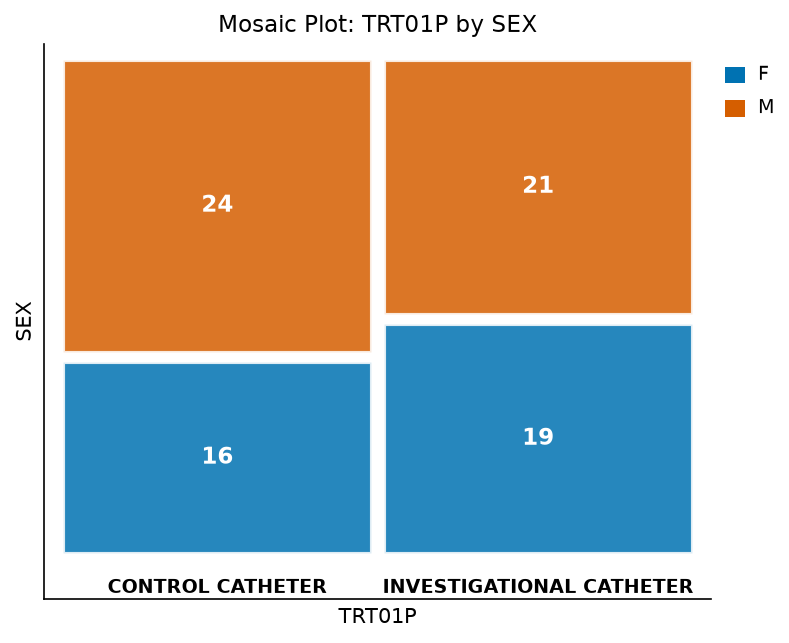

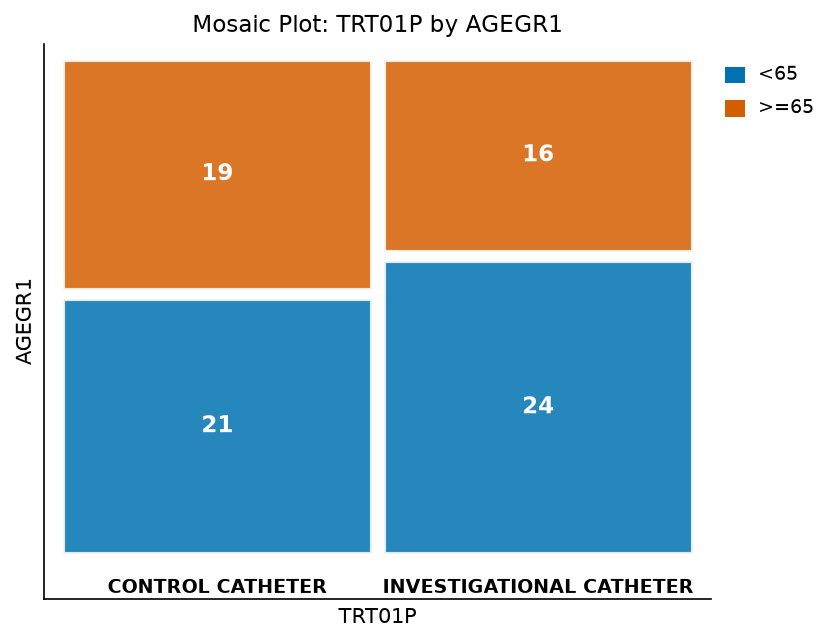

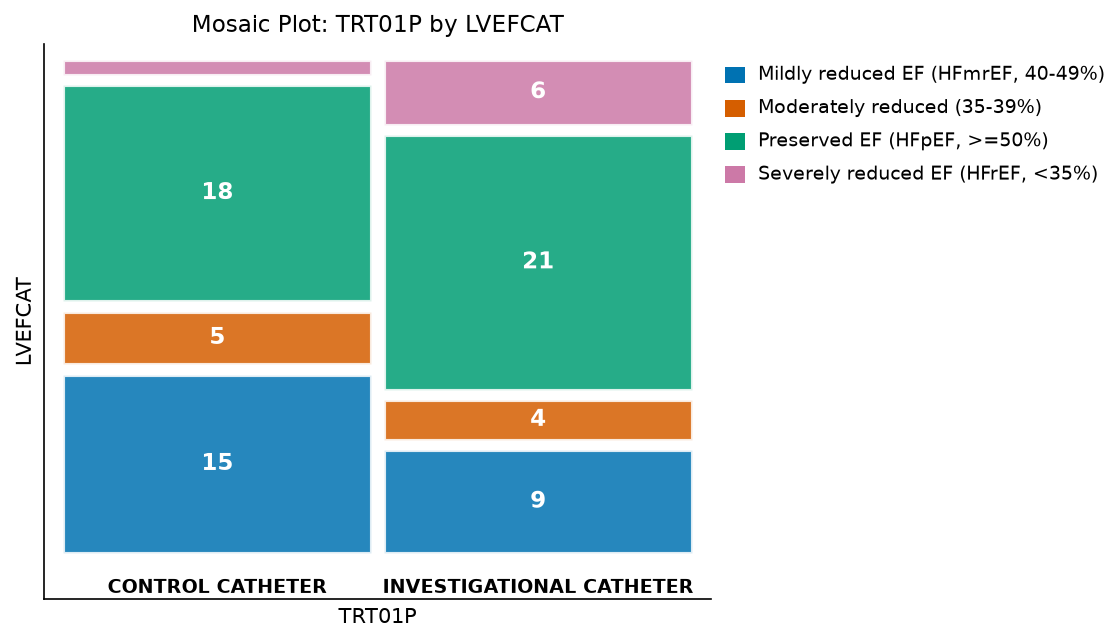

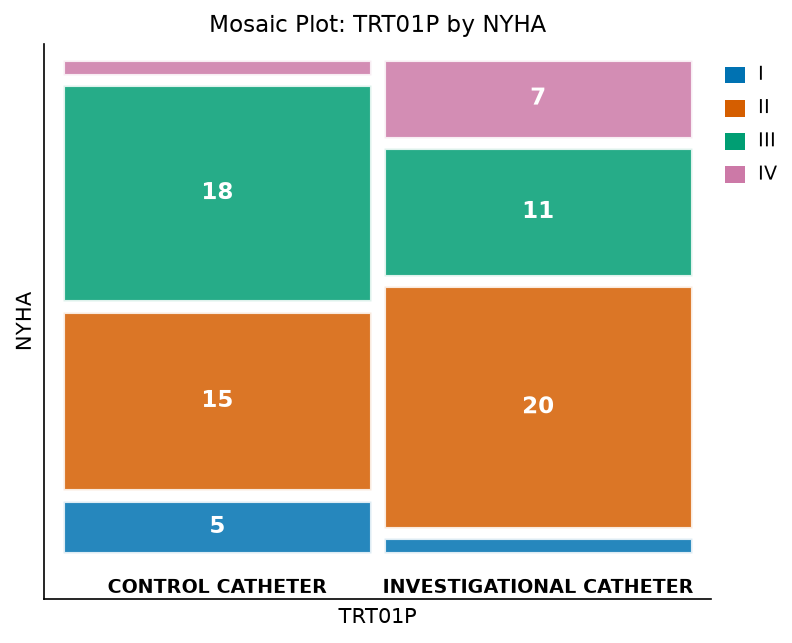

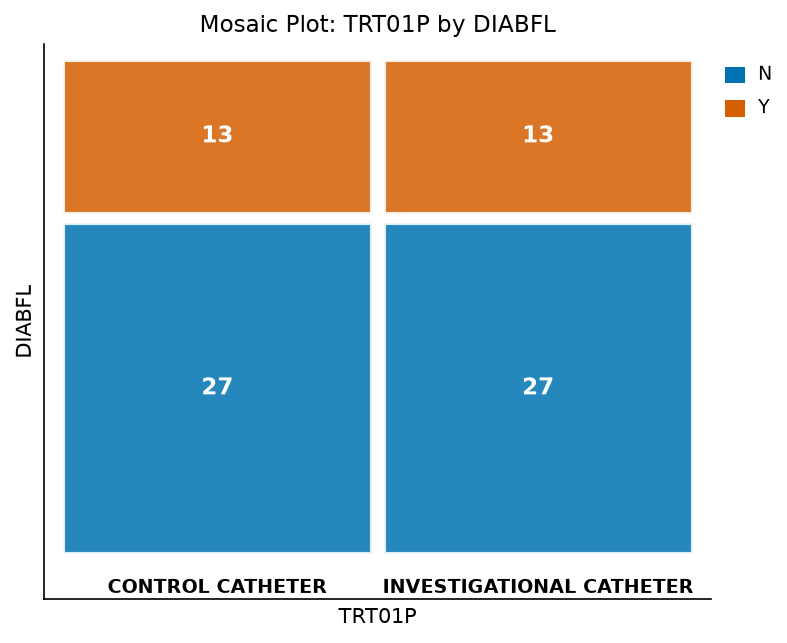

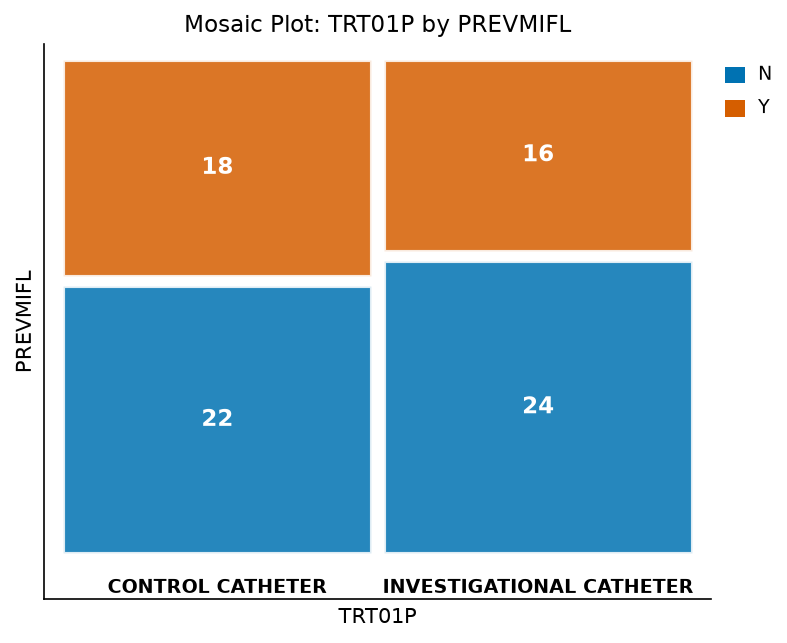

In [9]:
/* Sex distribution */
proc freq data=adsl;
    where ITTFL='Y';
    tables TRT01P * SEX / norow nopercent;
    format SEX $sexfmt.;
    title  'Table 14.1.1 (cont.) — Sex Distribution';
    title2 'Intent-to-Treat Population';
run;

/* Age groups */
proc freq data=adsl;
    where ITTFL='Y';
    tables TRT01P * AGEGR1 / norow nopercent;
    format AGEGR1 $agefmt.;
    title  'Table 14.1.1 (cont.) — Age Group';
    title2 'Intent-to-Treat Population';
run;

/* LVEF category */
proc freq data=adsl;
    where ITTFL='Y';
    tables TRT01P * LVEFCAT / norow nopercent;
    format LVEFCAT $lveffmt.;
    title  'Table 14.1.1 (cont.) — LVEF Category (2022 ACC/AHA Classification)';
    title2 'Intent-to-Treat Population';
run;

/* NYHA class */
proc freq data=adsl;
    where ITTFL='Y';
    tables TRT01P * NYHA / norow nopercent;
    format NYHA $nyha2fmt.;
    title  'Table 14.1.1 (cont.) — NYHA Functional Class at Baseline';
    title2 'Intent-to-Treat Population';
run;

/* Comorbidities */
proc freq data=adsl;
    where ITTFL='Y';
    tables TRT01P * DIABFL   / norow nopercent;
    tables TRT01P * PREVMIFL / norow nopercent;
    title  'Table 14.1.1 (cont.) — Comorbidities';
    title2 'Intent-to-Treat Population';
run;

title; title2; title3; footnote; footnote2; footnote3; footnote4;

---
## 3. Table 14.3.1 — Adverse Events by System Organ Class and Preferred Term

Table 14.3.1 is the primary safety table in an ICH E3 Section 12.3 submission package.

**Subject-level deduplication:** PROC SORT NODUPKEY on USUBJID-AESOC-AEDECOD ensures each subject is counted at most once per preferred term, regardless of how many episodes of that AE they experienced. This is the most common specification; some SAPs require counting episodes instead (sensitivity analysis only).

**Three-part table structure:**
- **Part A:** SOC-level summary — subjects with any AE in that SOC
- **Part B:** PT-level detail within each SOC — primary analysis table
- **Part C:** Serious adverse event (AESER=Y) listing by PT — regulatory required per   21 CFR 812.150 for device PMCFs (Post-Market Clinical Follow-up)

**Denominator anchoring:** N_ARM comes from the Safety Population (SAFFL='Y'), computed via PROC SQL before the frequency step. This is critical — using the AE dataset row count as the denominator would inflate percentages for subjects with multiple AEs.

In [10]:
/* ── Step 1: Deduplicate AEs to one record per subject per PT ── */
proc sort data=sdtm_ae nodupkey;
    by USUBJID AESOC AEDECOD;
run;

NOTE: PROC SORT data=sdtm_ae

NOTE: 2 duplicate observations were deleted.
NOTE: Read 55 rows from sdtm_ae.
NOTE: Wrote sdtm_ae (53 rows, 18 columns).
NOTE: PROC SORT statement used.


**Aggregate counts by SOC/PT and arm:**

In [11]:
/* ── Step 2: Count subjects with each SOC/PT per arm ────────── */
proc sql;
    /* N per arm (denominator) */
    create table n_arm as
    select TRT01P, count(distinct USUBJID) as N_ARM
    from adsl where SAFFL='Y'
    group by TRT01P;

    /* Subjects with AE by SOC, PT, and arm */
    create table ae_counts as
    select a.AESOC,
           a.AEDECOD,
           a.TRT01P,
           count(distinct a.USUBJID)   as N_SUBJ,
           b.N_ARM
    from sdtm_ae a
    inner join n_arm b on a.TRT01P = b.TRT01P
    where a.AESER ne 'missing'
    group by a.AESOC, a.AEDECOD, a.TRT01P, b.N_ARM;

    /* Add percentage */
    create table ae_pct as
    select AESOC, AEDECOD, TRT01P,
           N_SUBJ, N_ARM,
           round(N_SUBJ/N_ARM * 100, 0.1) as PCT
    from ae_counts
    order by AESOC, AEDECOD, TRT01P;
quit;

/* ── Step 3: SOC-level subject counts (any AE in that SOC) ──── */
proc sql;
    create table soc_any as
    select a.AESOC, a.TRT01P,
           count(distinct a.USUBJID) as N_SUBJ_SOC,
           b.N_ARM,
           round(count(distinct a.USUBJID)/b.N_ARM * 100, 0.1) as PCT_SOC
    from sdtm_ae a
    inner join n_arm b on a.TRT01P = b.TRT01P
    group by a.AESOC, a.TRT01P, b.N_ARM
    order by a.AESOC, a.TRT01P;
quit;

NOTE: PROC SQL 

NOTE: Table n_arm created.
NOTE: Table ae_counts created.
NOTE: Table ae_pct created.
NOTE: PROC SQL statement used.
NOTE: PROC SQL 

NOTE: Table soc_any created.
NOTE: PROC SQL statement used.


**Table 14.3.1 Part A — SOC summary:**

In [12]:
/* ── Step 4: Print Table 14.3.1 ─────────────────────────────── */
title  'Table 14.3.1  Treatment-Emergent Adverse Events';
title2 'by System Organ Class and Preferred Term';
title3 'Safety Population: CTL N=40, INV N=40';
footnote 'Subjects counted once per preferred term regardless of number of episodes.';
footnote2 'SOC = System Organ Class (MedDRA 26.0). PT = Preferred Term.';
footnote3 'Percentages based on number of subjects in each treatment arm.';

/* SOC-level summary */
proc report data=soc_any nowd;
    columns AESOC TRT01P N_SUBJ_SOC N_ARM PCT_SOC;
    define AESOC       / group 'System Organ Class' width=50;
    define TRT01P      / group 'Arm'                width=28;
    define N_SUBJ_SOC  / analysis 'n'               width=5  f=5.0;
    define N_ARM       / analysis 'N'               width=5  f=5.0;
    define PCT_SOC     / analysis '%'               width=7  f=6.1;
    title  'Table 14.3.1 — Part A: Any AE by System Organ Class';
    title2 'Safety Population';
run;

                                  Table 14.3.1 — Part A: Any AE by System Organ Class                                   
                                                   Safety Population                                                    
                                         Safety Population: CTL N=40, INV N=40                                          

System Organ Class                                  Arm                           n      N      %      
Cardiac disorders                                   CONTROL CATHETER              8      40     20     
Cardiac disorders                                   INVESTIGATIONAL CATHETER      7      40     17.50  
General disorders and administration site conditions  CONTROL CATHETER              7      40     17.50  
General disorders and administration site conditions  INVESTIGATIONAL CATHETER      3      40     7.50   
Infections and infestations                         CONTROL CATHETER              5      40     12.50  
Infectio

NOTE: Option TITLE changed to Table 14.3.1  Treatment-Emergent Adverse Events.
NOTE: Option TITLE2 changed to by System Organ Class and Preferred Term.
NOTE: Option TITLE3 changed to Safety Population: CTL N=40, INV N=40.
NOTE: Option FOOTNOTE changed to Subjects counted once per preferred term regardless of number of episodes..
NOTE: Option FOOTNOTE2 changed to SOC = System Organ Class (MedDRA 26.0). PT = Preferred Term..
NOTE: Option FOOTNOTE3 changed to Percentages based on number of subjects in each treatment arm..
NOTE: PROC REPORT data=soc_any

NOTE: PROC REPORT output 12 observations with 5 variables.

NOTE: Read 12 rows from soc_any.
NOTE: Wrote (console) (12 rows, 5 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


**Table 14.3.1 Part B — PT detail:**

In [13]:
/* PT-level detail */
proc report data=ae_pct nowd;
    columns AESOC AEDECOD TRT01P N_SUBJ N_ARM PCT;
    define AESOC   / group 'System Organ Class' width=40;
    define AEDECOD / group '  Preferred Term'   width=36;
    define TRT01P  / group 'Arm'                width=28;
    define N_SUBJ  / analysis 'n'               width=5  f=5.0;
    define N_ARM   / analysis 'N'               width=5  f=5.0;
    define PCT     / analysis '%'               width=7  f=6.1;
    title  'Table 14.3.1 — Part B: AE Preferred Terms by System Organ Class';
    title2 'Safety Population  (sorted by SOC, then PT)';
run;

                            Table 14.3.1 — Part B: AE Preferred Terms by System Organ Class                             
                                      Safety Population  (sorted by SOC, then PT)                                       
                                         Safety Population: CTL N=40, INV N=40                                          

System Organ Class                          Preferred Term                      Arm                           n      N      %      
Cardiac disorders                         Atrial fibrillation                   CONTROL CATHETER              3      40     7.50   
Cardiac disorders                         Atrial fibrillation                   INVESTIGATIONAL CATHETER      5      40     12.50  
Cardiac disorders                         Cardiac failure congestive            CONTROL CATHETER              3      40     7.50   
Cardiac disorders                         Cardiac failure congestive            INVESTIGATIONAL CATHETER    

NOTE: PROC REPORT data=ae_pct

NOTE: PROC REPORT output 25 observations with 6 variables.

NOTE: Read 25 rows from ae_pct.
NOTE: Wrote (console) (25 rows, 6 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


**Table 14.3.1 Part C — Serious AEs:**

In [14]:
/* Serious AE summary.
   ODS GRAPHICS is turned OFF for this step: with one row per serious
   preferred term, the default 2-way mosaic plot would carry ~11
   overlapping category labels and add no analytical value. The
   regulatory deliverable here is the frequency table itself.        */
ods graphics off;
proc freq data=sdtm_ae;
    where AESER='Y';
    tables AEDECOD * TRT01P / norow nopercent;
    title  'Table 14.3.1 — Part C: Serious Adverse Events (AESER=Y) by Preferred Term';
    title2 'Safety Population';
run;
ods graphics on;

title; title2; title3; footnote; footnote2; footnote3;

                       Table 14.3.1 — Part C: Serious Adverse Events (AESER=Y) by Preferred Term                        
                                      Safety Population  (sorted by SOC, then PT)                                       
                                         Safety Population: CTL N=40, INV N=40                                          

                                                   The FREQ Procedure

Table of Dictionary-Derived Term by Planned Treatment for Period 01

Dictionary-Derived Term    |        CONTROL CATHETER |INVESTIGATIONAL CATHETER |                    Total
---------------------------+-------------------------+-------------------------+-------------------------
Atrial fibrillation        |                       0 |                       4 |                        4
---------------------------+-------------------------+-------------------------+-------------------------
Cardiac failure congestive |                       0 |                  

NOTE: ODS Graphics is OFF.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Results Summary

All figures below are read directly from the executed tables above
(Safety / ITT Population = 80 subjects, 40 per arm).

**Table 14.1.1 key findings:**
- Arm balance confirmed (40 / 40) for every baseline characteristic.
- Age: CONTROL 64.5 years (SD 8.1) vs INVESTIGATIONAL 61.6 years
  (SD 9.7) — a 2.9-year difference that would be carried as a
  covariate in the primary ANCOVA.
- LVEF at screening balanced across arms: CONTROL mean 48.4%
  (SD 10.3), INVESTIGATIONAL 49.1% (SD 12.7).
- NYHA Class II/III dominates: 64 of 80 subjects (80%) — CONTROL
  33/40 (Class II 15, III 18), INVESTIGATIONAL 31/40 (Class II 20,
  III 11) — appropriate entry criteria for a haemodynamic-support
  catheter.
- Comorbidities balanced and consistent with the cardiovascular
  catheter trial literature: diabetes 26/80 (32.5%; 13 per arm),
  prior MI 34/80 (42.5%; CONTROL 18, INVESTIGATIONAL 16).

**Table 14.3.1 key findings:**
- Subject AE incidence: 30 of 80 Safety-Population subjects (37.5%)
  reported at least one treatment-emergent AE — and the incidence is
  identical in the two arms (15/40 = 37.5% each).
- Most frequent SOC: **Cardiac disorders**, affecting 15 distinct
  subjects (CONTROL 8/40 = 20.0%, INVESTIGATIONAL 7/40 = 17.5%) —
  appropriate for the enrolled heart-failure population.
- Second most frequent SOC: **General disorders and administration
  site conditions** (10 subjects), followed by Infections and
  infestations (8) and Vascular disorders (7).
- Serious adverse events: 17 of 80 subjects (21.3%) experienced at
  least one serious AE; the Part C listing tabulates 20 serious
  subject-by-preferred-term events (7 in CONTROL, 13 in
  INVESTIGATIONAL), led by Atrial fibrillation (4 events, all in the
  INVESTIGATIONAL arm).
- Deduplication applied: PROC SORT NODUPKEY removed 2 duplicate
  subject/SOC/PT records before tabulation, so each subject is
  counted at most once per preferred term regardless of episode
  count.

**Regulatory notes:**
- PROC SORT NODUPKEY on USUBJID-AESOC-AEDECOD is the standard
  mechanism for subject-level deduplication.
- The TRT01P label ("Planned Treatment for Period 01") and value
  decoding display the full treatment name for clarity in the
  regulatory submission.
- SOC/PT ordering follows the MedDRA hierarchy (alphabetical within
  SOC, then alphabetical by PT).
- In a production package these tables would feed the Integrated
  Summary of Safety (ISS) and be validated against the independent
  programmer's parallel output using PROC COMPARE with the NOVALUES
  option.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute medical, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>